# **Setup**

In [60]:
# Estou utilizando o drive para carregar os datasets direto de lá
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [61]:
!pip install torch
!pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.6.0+cu124.html
!pip install torch-geometric
!pip install torch-geometric-temporal
!pip install numpy pandas tqdm scikit-learn matplotlib loguru torchmetrics timesfm

Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html


In [62]:
import sys
sys.path.append('/content/drive/MyDrive/ColabData/LABIA/DatasetsTSFM')

In [63]:
# basic
import os
import pickle
import warnings
import numpy as np
import pandas as pd
from tqdm import tqdm
# pre processing
from sklearn import preprocessing as pre
# NN
import torch
import torch.nn as nn
from torch import Tensor
import torch.nn.functional as F
import torch.optim as optim
from torch.nn import MSELoss
from torch_geometric.nn import GCNConv
# val and plot
from torchmetrics.regression import R2Score
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_absolute_error
from loguru import logger as log
from val import calculate_metrics
# plot
import matplotlib.pyplot as plt
# foundation model
import timesfm
from functools import reduce



In [64]:
plt.style.use("seaborn-v0_8-whitegrid")

# **Experimento**

In [65]:
SEED = 1345
def seed_everything(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
seed_everything(SEED)
warnings.filterwarnings('ignore')

In [66]:
print(torch.__version__)
print(torch.version.cuda)

2.6.0+cu124
12.4


In [67]:
sb = pd.read_parquet("/content/drive/MyDrive/ColabData/LABIA/DatasetsTSFM/loader_03-04_2024.parquet")
sb.head()

,125960550,230565994,258781031,43768720,44072192,44783654,44783914,44784438,45833547,47568123
2024-03-01 05:00:00,1.333333,0.000000,70.792221,41.188599,1.724359,14.955100,2.032506,3.571820,5.877792,7.546274
2024-03-01 05:30:00,3.595238,1.583333,229.051071,172.071198,8.282966,44.559937,11.048912,18.211931,18.912033,18.276293
2024-03-01 06:00:00,4.812975,3.268518,424.853729,433.062469,18.825665,97.263435,26.276600,41.471294,40.731876,37.141144
2024-03-01 06:30:00,9.215629,5.256614,630.444153,743.177368,25.593414,149.329544,49.763138,71.520836,57.200085,53.487366
2024-03-01 07:00:00,12.585028,6.152447,841.874512,1132.739502,44.350349,204.275940,78.721497,107.241295,77.808769,75.446609


In [68]:
sb.shape

(3640, 10)

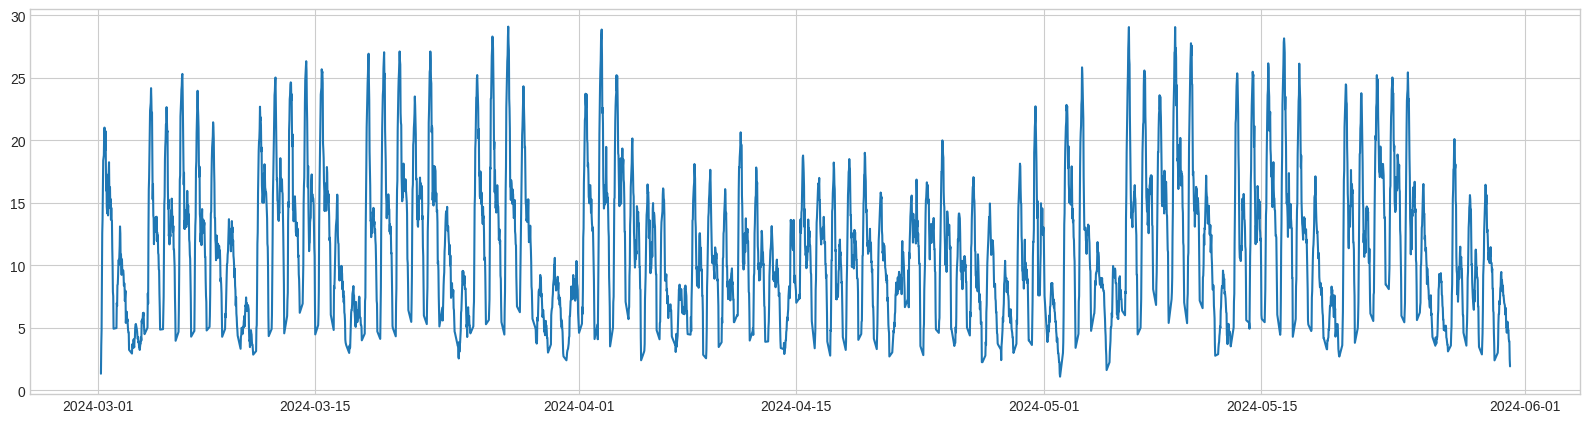

In [69]:
plt.figure(figsize=(20, 5))
plt.plot(sb["125960550"])
plt.show()

In [70]:
# define X and Y
sbx = sb.query("index <= '2024-03-31 23:59:59'")
sbx.shape, sb.shape

((1238, 10), (3640, 10))

In [71]:
# define X and Y
sby = sb.query("index > '2024-03-31 23:59:59'")
sby.shape, sb.shape

((2402, 10), (3640, 10))

In [72]:
pred_len = abs(sbx.shape[0] - sb.shape[0])
pred_len

2402

In [73]:
sbx

,125960550,230565994,258781031,43768720,44072192,44783654,44783914,44784438,45833547,47568123
2024-03-01 05:00:00,1.333333,0.000000,70.792221,41.188599,1.724359,14.955100,2.032506,3.571820,5.877792,7.546274
2024-03-01 05:30:00,3.595238,1.583333,229.051071,172.071198,8.282966,44.559937,11.048912,18.211931,18.912033,18.276293
2024-03-01 06:00:00,4.812975,3.268518,424.853729,433.062469,18.825665,97.263435,26.276600,41.471294,40.731876,37.141144
2024-03-01 06:30:00,9.215629,5.256614,630.444153,743.177368,25.593414,149.329544,49.763138,71.520836,57.200085,53.487366
2024-03-01 07:00:00,12.585028,6.152447,841.874512,1132.739502,44.350349,204.275940,78.721497,107.241295,77.808769,75.446609
...,...,...,...,...,...,...,...,...,...,...
2024-03-31 21:30:00,8.525162,14.713684,466.679504,572.464783,40.153152,67.748451,140.110031,72.992035,16.047325,73.139664
2024-03-31 22:00:00,8.358495,11.963684,457.153748,544.450256,36.960098,61.056091,131.402695,69.995026,16.213991,70.889061
2024-03-31 22:30:00,8.032619,10.797018,435.691376,514.735413,36.256763,54.854801,123.299950,66.389008,13.727880,66.752312
2024-03-31 23:00:00,6.199285,10.463684,404.983246,480.096191,31.831995,49.224724,113.868469,61.778755,9.897774,63.470806


In [78]:
model_name = 'timesfm-2.0-500m-pytorch'

if model_name == 'timesfm-2.0-500m-pytorch':
  tfm = timesfm.TimesFm(
      hparams=timesfm.TimesFmHparams(
          backend="gpu",
          per_core_batch_size=40,
          horizon_len=pred_len,
          num_layers=50,
          use_positional_embedding=False,
          context_len=2048,

      ),
      checkpoint=timesfm.TimesFmCheckpoint(
                    huggingface_repo_id=(''.join(('google/', model_name))),
      )
)

elif model_name == 'timesfm-1.0-200m-pytorch':
  tfm = timesfm.TimesFm(
      hparams=timesfm.TimesFmHparams(
          backend="gpu",
          per_core_batch_size=40,
          horizon_len=pred_len,
      ),
  checkpoint=timesfm.TimesFmCheckpoint(
                    huggingface_repo_id=(''.join(('google/', model_name))),
      )
  )

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

In [79]:
nodes = sb.columns
nodes

Index(['125960550', '230565994', '258781031', '43768720', '44072192',
       '44783654', '44783914', '44784438', '45833547', '47568123'],
      dtype='object')

In [80]:
scores_error = {'node':[], 'mae': [], 'mse': [], 'r2': [], 'mape': []}
targets = {}
for node in nodes:
    targets[node] = []
    forecast, experimental_quantile_forecast = tfm.forecast(
            [sbx[node]],
            freq=[0],
    )

    y_hat = torch.tensor(forecast[0])
    y_pred =  y_hat.cpu().data.numpy()
    y_true = sby[node].values

    scores_error['node'].append(node)
    scores_error['mse'].append(mean_squared_error(y_true, y_pred))
    scores_error['mae'].append(mean_absolute_error(y_true, y_pred))
    scores_error['r2'].append(r2_score(y_true, y_pred))
    scores_error['mape'].append(mean_absolute_percentage_error(y_true, y_pred))

    targets[node].append({"input":  np.array(sbx[node]),
                              'true': y_true,
                              'pred': y_pred,
                              'node': node
                             })


In [81]:
with open(f'{model_name}-targets-long.pkl', 'wb') as f:
    pickle.dump(targets, f)

In [56]:
df_results = pd.DataFrame(scores_error)
df_results

,node,mae,mse,r2,mape
0,125960550,5.217198,4.461054e+01,-0.517737,0.460801
1,230565994,10.540692,2.697636e+02,-0.110351,0.497007
2,258781031,458.964233,2.796270e+05,-0.215551,0.529157
3,43768720,924.195129,1.212391e+06,-0.598158,0.621192
4,44072192,67.034660,6.127546e+03,-0.697350,0.692290
5,44783654,142.808990,3.440140e+04,-0.998323,0.626748
6,44783914,188.527847,5.932392e+04,-0.643282,0.571311
7,44784438,108.413353,1.651421e+04,-0.094736,0.520625
8,45833547,44.297897,3.129900e+03,-0.382130,0.765729
9,47568123,119.493156,1.710169e+04,-3.882872,1.083932


In [57]:
df_results["model"] = model_name

In [58]:
df_results[['model', 'node', 'mae', 'mse', 'r2', 'mape']]

,model,node,mae,mse,r2,mape
0,timesfm-1.0-200m-pytorch,125960550,5.217198,4.461054e+01,-0.517737,0.460801
1,timesfm-1.0-200m-pytorch,230565994,10.540692,2.697636e+02,-0.110351,0.497007
2,timesfm-1.0-200m-pytorch,258781031,458.964233,2.796270e+05,-0.215551,0.529157
3,timesfm-1.0-200m-pytorch,43768720,924.195129,1.212391e+06,-0.598158,0.621192
4,timesfm-1.0-200m-pytorch,44072192,67.034660,6.127546e+03,-0.697350,0.692290
5,timesfm-1.0-200m-pytorch,44783654,142.808990,3.440140e+04,-0.998323,0.626748
6,timesfm-1.0-200m-pytorch,44783914,188.527847,5.932392e+04,-0.643282,0.571311
7,timesfm-1.0-200m-pytorch,44784438,108.413353,1.651421e+04,-0.094736,0.520625
8,timesfm-1.0-200m-pytorch,45833547,44.297897,3.129900e+03,-0.382130,0.765729
9,timesfm-1.0-200m-pytorch,47568123,119.493156,1.710169e+04,-3.882872,1.083932


In [59]:
df_results.to_csv(''.join((model_name, '-long.csv')))